<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/Manuja/VGG16_Garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
cd "/content/drive/MyDrive/Colab Notebooks/DL_Assignment"

/content/drive/MyDrive/Colab Notebooks/DL_Assignment


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [3]:
# Define paths and parameters
train_dir = '/content/drive/MyDrive/Colab Notebooks/DL_Assignment/DATASET/TRAIN'
test_dir = '/content/drive/MyDrive/Colab Notebooks/DL_Assignment/DATASET/TEST'
img_width, img_height = 224, 224 # VGG16 input size
batch_size = 64

# Data pre processing and augmentation

In [4]:
# Create ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values
    shear_range=0.2, # Apply shear augmentation
    zoom_range=0.2, # Apply zoom augmentation
    horizontal_flip=True) # Apply horizontal flip augmentation

# Create ImageDataGenerator for testing (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255) # Normalize pixel values

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary') # Use 'binary' for binary classification

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary') # Use 'binary' for binary classification

# Map class indices to labels
class_labels = {0: 'Organic', 1: 'Recycle'}

Found 22592 images belonging to 2 classes.
Found 2514 images belonging to 2 classes.


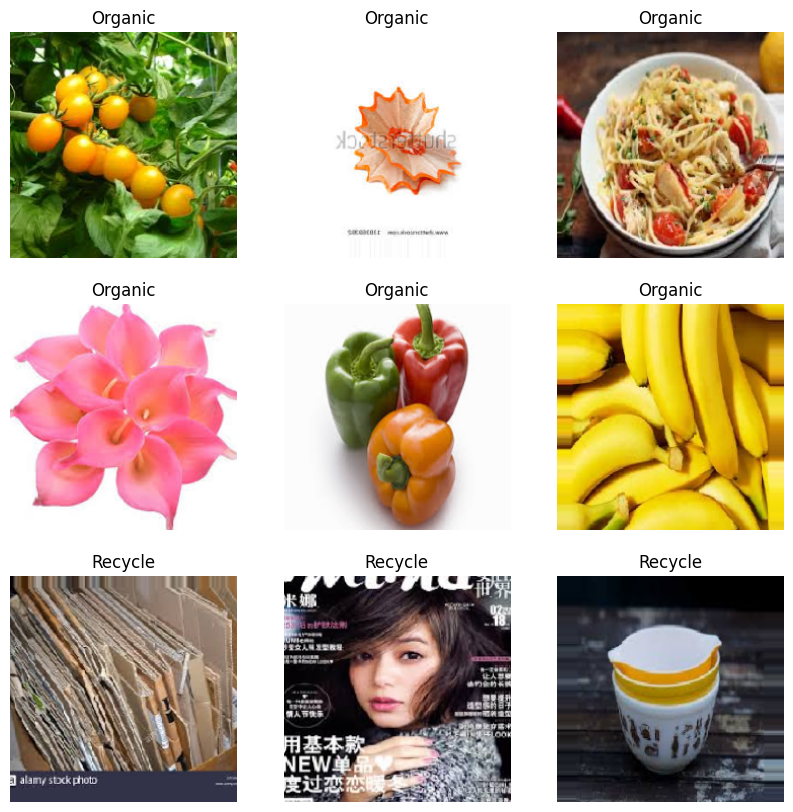

In [5]:
import matplotlib.pyplot as plt

# Get a batch of images and labels from the training generator
images, labels = next(train_generator)

# Get the class names from the generator
class_names = list(train_generator.class_indices.keys())

# Plot the first 9 images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_labels[int(labels[i])]) # Use the updated class_labels dictionary
    plt.axis("off")
plt.show()

## Load vgg16 base model




In [6]:
# Load the VGG16 model with pre-trained ImageNet weights, excluding the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Freeze the layers of the base model to prevent their weights from being updated during training
for layer in base_model.layers:
    layer.trainable = False

## Add custom layers

### Subtask:
Add new layers on top of the VGG16 base for binary classification.


**Reasoning**:
Implement the steps to add new layers on top of the VGG16 base for binary classification using the instructions provided.



In [7]:
from tensorflow.keras import regularizers

# Get the output of the base_model
x = base_model.output

# Add a Flatten layer
x = Flatten()(x)

# Add a Dense layer with 256 units, ReLU activation, and L2 regularization
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x) # Added L2 regularization

# Add a Dropout layer with a dropout rate of 0.5
x = Dropout(0.5)(x)

# Add a final Dense layer with 1 unit and a sigmoid activation function for binary classification
# Adding L2 regularization here as well
predictions = Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001))(x) # Added L2 regularization

# Create a new Model
model = Model(inputs=base_model.input, outputs=predictions)

In [8]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
# Monitor 'val_loss' (validation loss)
# patience=3 means training will stop if validation loss doesn't improve for 3 consecutive epochs
# restore_best_weights=True will keep the weights from the epoch with the best validation loss
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

epochs = 10  # You can adjust the number of epochs, but early stopping will stop training sooner if needed

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size,
    callbacks=[early_stopping]) # Add the early stopping callback here

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 460s 1s/step - accuracy: 0.8344 - loss: 0.7671 - val_accuracy: 0.8758 - val_loss: 0.5679
Epoch 2/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.8929 - loss: 0.4864 - val_accuracy: 0.8878 - val_loss: 0.4805
Epoch 3/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 363s 1s/step - accuracy: 0.9007 - loss: 0.4043 - val_accuracy: 0.8858 - val_loss: 0.4461
Epoch 4/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.9054 - loss: 0.3690 - val_accuracy: 0.8838 - val_loss: 0.4423
Epoch 5/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 360s 1s/step - accuracy: 0.9110 - loss: 0.3389 - val_accuracy: 0.8818 - val_loss: 0.4314
Epoch 6/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.9145 - loss: 0.3147 - val_accuracy: 0.8854 - val_loss: 0.4253
Epoch 7/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 357s 1s/step - accuracy: 0.9194 - loss: 0.2985 - val_accuracy: 0.8878 - val_loss: 0.3859
Epoch 8/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.9233 - loss: 0.2878 - val_accu

In [13]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 491ms/step - accuracy: 0.8905 - loss: 0.3677
Test Loss: 0.3620
Test Accuracy: 0.8954


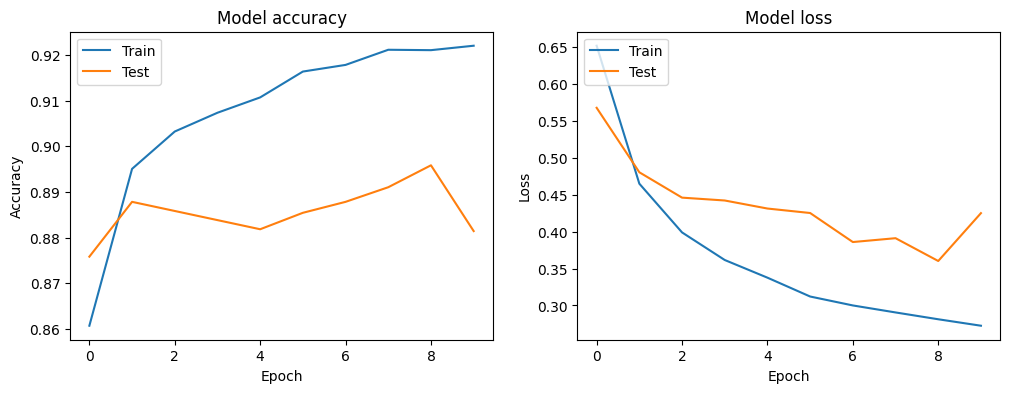

In [12]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

In [15]:
# Define the path where you want to save the weights
weights_save_path = '/content/drive/MyDrive/Colab Notebooks/DL_Assignment/garbage_classification_weights.weights.h5' # Corrected filename

# Save the model weights
model.save_weights(weights_save_path)

print(f"Model weights saved to: {weights_save_path}")

Model weights saved to: /content/drive/MyDrive/Colab Notebooks/DL_Assignment/garbage_classification_weights.weights.h5
